# 🏆 Algorithm Tournament — Personalized Productivity Monitoring System
### Goal: Predict `user_score` (0–10 integer) + recommendation vectors `v_t, v_h, v_l, v_n` from sensor readings
**Split:** 80 % Train / 20 % Test &nbsp;|&nbsp; **5 Algorithms:** Random Forest · XGBoost · KNN · MLP · SVM

**Metrics used to judge winner:**
- `Accuracy` — exact integer match
- `MAE` — mean absolute error (penalises off-by-2 more than off-by-1)
- `F1-Macro` — balanced across all score classes (0–10)
- `Vector Exact-Match` — all 4 vectors correct simultaneously
- `Fit Time` — inference practicality for real-time IoT edge deployment

## 0 · Install dependencies

In [1]:
# Run once; restart kernel if needed
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn --quiet


[notice] A new release of pip is available: 25.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1 · Imports & Reproducibility

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import (
    accuracy_score, mean_absolute_error,
    f1_score, classification_report, confusion_matrix
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

SEED = 42
np.random.seed(SEED)
print('Imports OK ✓')

Imports OK ✓


## 2 · Load Dataset

In [3]:
# ⚠️  Update this path to point at your CSV file
CSV_PATH = 'productivity_monitoring_dataset_v2.csv'

df = pd.read_csv(CSV_PATH, parse_dates=['timestamp'])
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (2500, 10)
Columns: ['timestamp', 'temp', 'humid', 'lux', 'noise', 'user_score', 'v_t', 'v_h', 'v_l', 'v_n']


,timestamp,temp,humid,lux,noise,user_score,v_t,v_h,v_l,v_n
0,2026-03-27 09:00:00,21.98,52.01,184.4,62.0,9,0,0,0,0
1,2026-03-27 09:20:00,21.98,52.00,182.0,58.4,9,0,0,0,0
2,2026-03-27 09:40:00,21.96,52.02,68.0,60.8,9,0,0,0,0
3,2026-03-27 10:00:00,21.96,52.03,85.5,64.5,9,0,0,0,0
4,2026-03-27 10:20:00,21.92,52.11,101.3,66.5,9,0,0,0,0


## 3 · Exploratory Data Analysis

In [4]:
print('=== Basic Stats ===')
print(df[['temp','humid','lux','noise','user_score']].describe().round(2))

print('\n=== Score Distribution ===')
print(df['user_score'].value_counts().sort_index())

print('\n=== Productivity Tier ===')
df['tier'] = pd.cut(df['user_score'],
                     bins=[-1, 5, 7, 10],
                     labels=['Big Change (<6)', 'Slight Change (6-7)', 'Optimal (>=8)'])
print(df['tier'].value_counts())

=== Basic Stats ===
          temp    humid      lux    noise  user_score
count  2500.00  2500.00  2500.00  2500.00     2500.00
mean     19.07    54.80    94.28   162.46        8.32
std       0.66     0.79    76.84   142.42        1.68
min      17.98    52.00    10.00    20.00        3.00
25%      18.63    54.25    28.60    53.40        8.00
50%      19.01    54.81    70.65   111.75        9.00
75%      19.35    55.44   153.80   230.42        9.00
max      22.26    56.45   556.80   800.00       10.00

=== Score Distribution ===
user_score
3      44
4      94
5     112
6     115
7     104
8     506
9     990
10    535
Name: count, dtype: int64

=== Productivity Tier ===
tier
Optimal (>=8)          2031
Big Change (<6)         250
Slight Change (6-7)     219
Name: count, dtype: int64


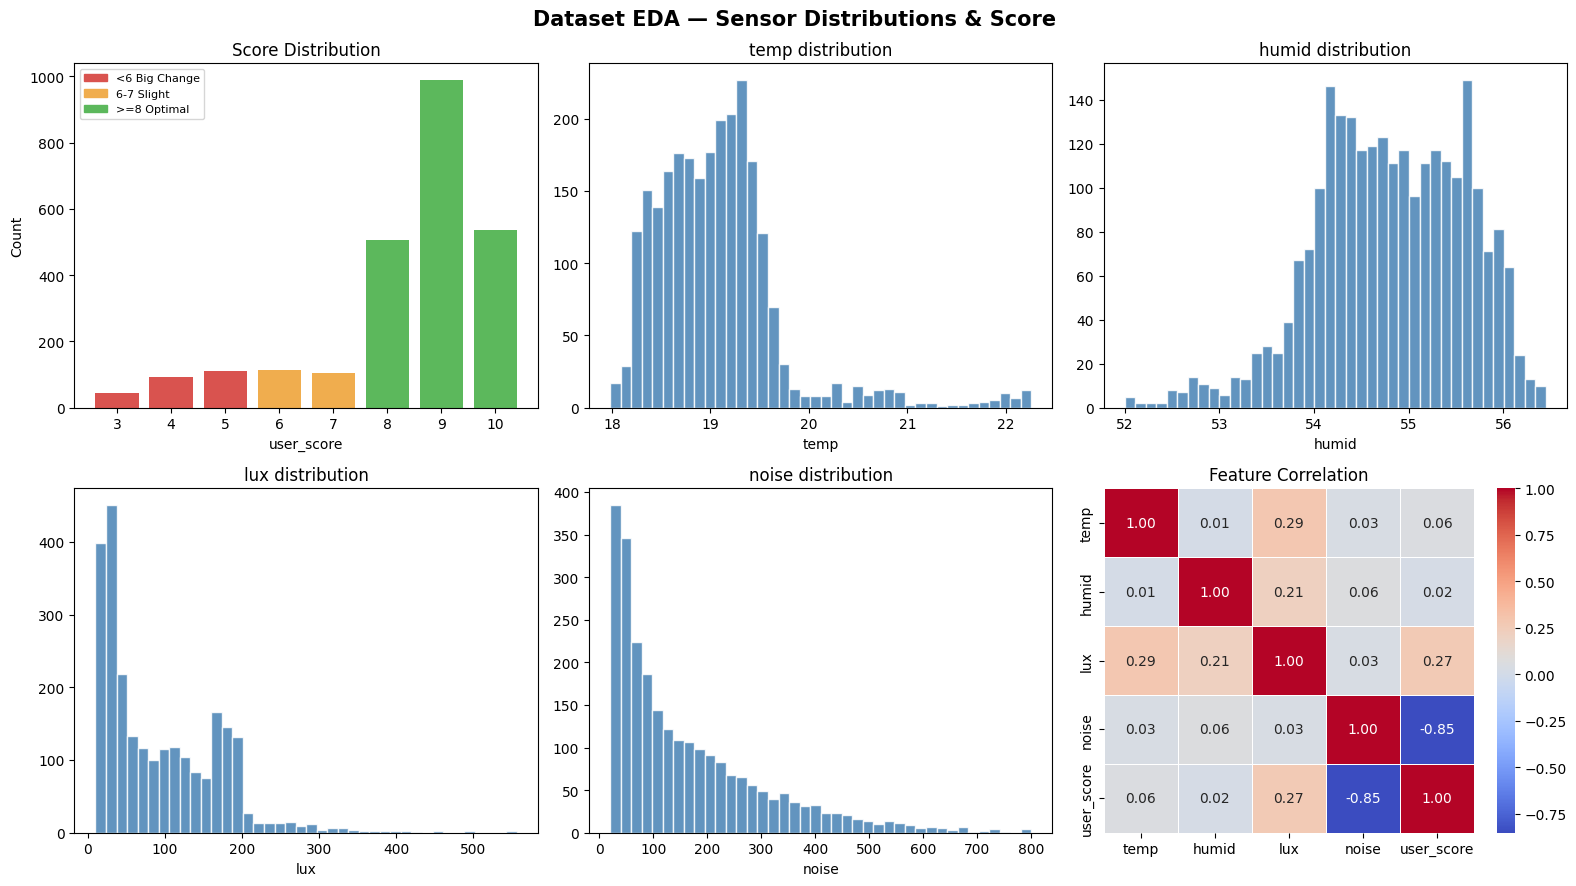

EDA saved → eda_overview.png


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Dataset EDA — Sensor Distributions & Score', fontsize=15, fontweight='bold')

# Score distribution
ax = axes[0, 0]
counts = df['user_score'].value_counts().sort_index()
bars = ax.bar(counts.index, counts.values,
              color=['#d9534f' if s < 6 else '#f0ad4e' if s < 8 else '#5cb85c' for s in counts.index])
ax.set_title('Score Distribution'); ax.set_xlabel('user_score'); ax.set_ylabel('Count')
ax.legend(handles=[
    plt.Rectangle((0,0),1,1, color='#d9534f', label='<6 Big Change'),
    plt.Rectangle((0,0),1,1, color='#f0ad4e', label='6-7 Slight'),
    plt.Rectangle((0,0),1,1, color='#5cb85c', label='>=8 Optimal')
], fontsize=8)

# Sensor histograms
for idx, (col, ax) in enumerate(zip(['temp','humid','lux','noise'], axes.flat[1:5])):
    ax.hist(df[col], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_title(f'{col} distribution'); ax.set_xlabel(col)

# Correlation heatmap
ax = axes[1, 2]
corr = df[['temp','humid','lux','noise','user_score']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=120, bbox_inches='tight')
plt.show()
print('EDA saved → eda_overview.png')

## 4 · Feature Engineering & Train/Test Split

In [6]:
FEATURES = ['temp', 'humid', 'lux', 'noise']
SCORE_TARGET = 'user_score'
VEC_TARGETS  = ['v_t', 'v_h', 'v_l', 'v_n']

X = df[FEATURES].values
y_score = df[SCORE_TARGET].values          # integer 0-10
y_vec   = df[VEC_TARGETS].values           # shape (N, 4)

# Stratify on score so every class appears in both splits
X_tr, X_te, ys_tr, ys_te, yv_tr, yv_te = train_test_split(
    X, y_score, y_vec,
    test_size=0.20, random_state=SEED, stratify=y_score
)

print(f'Train samples : {len(X_tr):,}  ({100*len(X_tr)/(len(X_tr)+len(X_te)):.0f}%)')
print(f'Test  samples : {len(X_te):,}  ({100*len(X_te)/(len(X_tr)+len(X_te)):.0f}%)')
print(f'Features      : {FEATURES}')
print(f'Score classes in test: {sorted(np.unique(ys_te))}')

Train samples : 2,000  (80%)
Test  samples : 500  (20%)
Features      : ['temp', 'humid', 'lux', 'noise']
Score classes in test: [3, 4, 5, 6, 7, 8, 9, 10]


## 5 · Define the 5 Algorithms

In [7]:
# Each entry: (name, score_pipeline, vec_pipeline)
# Vectors are multi-output → wrapped in MultiOutputClassifier where needed

def make_models():
    rf  = RandomForestClassifier(n_estimators=200, max_depth=None,
                                  random_state=SEED, n_jobs=-1)
    xgb = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                         use_label_encoder=False, eval_metric='mlogloss',
                         random_state=SEED, verbosity=0)
    knn = KNeighborsClassifier(n_neighbors=7, weights='distance', n_jobs=-1)
    mlp = MLPClassifier(hidden_layer_sizes=(128, 64, 32), activation='relu',
                         max_iter=500, random_state=SEED, early_stopping=True)
    svm = SVC(kernel='rbf', C=10, gamma='scale', decision_function_shape='ovr',
               random_state=SEED)

    models = {
        'Random Forest' : rf,
        'XGBoost'       : xgb,
        'KNN'           : knn,
        'MLP (Neural Net)': mlp,
        'SVM'           : svm,
    }
    return models

print('Models defined:')
for name in make_models(): print(f'  ✓ {name}')

Models defined:
  ✓ Random Forest
  ✓ XGBoost
  ✓ KNN
  ✓ MLP (Neural Net)
  ✓ SVM


## 6 · Run the Tournament

In [15]:
import time
import copy
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score, mean_absolute_error, f1_score
from sklearn.model_selection import train_test_split # Ensure this is used for splitting
from xgboost import XGBClassifier

# ── 1. STRATIFIED SPLIT (Prevents "1 Class" Error) ──
# If you haven't split your data yet, use 'stratify' like this:
# X_tr, X_te, ys_tr, ys_te = train_test_split(X, ys, test_size=0.2, stratify=ys, random_state=42)

# ── 2. PRE-PROCESS SCORE LABELS ──
le = LabelEncoder()
ys_tr_encoded = le.fit_transform(ys_tr)
ys_te_encoded = le.transform(ys_te)

# Check if we actually have more than one class after encoding
num_unique_classes = len(np.unique(ys_tr_encoded))
if num_unique_classes < 2:
    print(f"⚠️ WARNING: Training set only has {num_unique_classes} class. SVM/XGB will fail.")

# ── 3. PRE-PROCESS VECTOR LABELS (Ensure Binary 0/1) ──
yv_tr_clean = np.where(yv_tr > 0, 1, 0)
yv_te_clean = np.where(yv_te > 0, 1, 0)

results = []

for name, clf in make_models().items():
    print('\n' + '=' * 55)
    print(f'   Training: {name}')
    print('=' * 55)

    current_clf = copy.deepcopy(clf)
    needs_scaling = name in ['KNN', 'MLP (Neural Net)', 'SVM']
    
    # ── A. SCORE PREDICTOR ──
    if needs_scaling:
        score_pipe = Pipeline([('scaler', StandardScaler()), ('clf', current_clf)])
    else:
        score_pipe = current_clf

    try:
        # Check if we can actually train this model on this data
        if name == 'SVM' and num_unique_classes < 2:
            print(f'   Skipping {name}: Requires at least 2 classes.')
            continue

        t0 = time.time()
        score_pipe.fit(X_tr, ys_tr_encoded)
        fit_time = time.time() - t0

        ys_pred_encoded = score_pipe.predict(X_te)
        ys_pred = le.inverse_transform(ys_pred_encoded)

        acc  = accuracy_score(ys_te, ys_pred)
        mae  = mean_absolute_error(ys_te, ys_pred)
        f1   = f1_score(ys_te, ys_pred, average='macro', zero_division=0)
        
        # ── B. VECTOR PREDICTOR ──
        base_vec = copy.deepcopy(clf)
        
        # Prevent nested parallelism errors (The RemoteTraceback fix)
        if hasattr(base_vec, 'n_jobs'):
            base_vec.set_params(n_jobs=1) 

        if needs_scaling:
            vec_pipe = Pipeline([
                ('scaler', StandardScaler()), 
                ('clf', MultiOutputClassifier(base_vec, n_jobs=-1))
            ])
        else:
            vec_pipe = MultiOutputClassifier(base_vec, n_jobs=-1)

        vec_pipe.fit(X_tr, yv_tr_clean)
        yv_pred = vec_pipe.predict(X_te)
        vec_exact = np.mean(np.all(yv_pred == yv_te_clean, axis=1))

        print(f'   Score Accuracy      : {acc:.4f}')
        print(f'   Score MAE           : {mae:.4f}')
        print(f'   Score F1-Macro      : {f1:.4f}')
        print(f'   Vector Exact-Match  : {vec_exact:.4f}')
        print(f'   Fit Time            : {fit_time:.2f}s')

        results.append({
            'Algorithm'          : name,
            'Accuracy'           : acc,
            'MAE'                : mae,
            'F1-Macro'           : f1,
            'Vector Exact-Match' : vec_exact,
            'Fit Time (s)'       : fit_time
        })

    except Exception as e:
        print(f'   ❌ Error training {name}: {str(e)[:100]}...')
        continue

print('\n✅ Tournament complete!')


   Training: Random Forest
   Score Accuracy      : 0.7620
   Score MAE           : 0.2380
   Score F1-Macro      : 0.7867
   Vector Exact-Match  : 0.9840
   Fit Time            : 0.43s

   Training: XGBoost
   Score Accuracy      : 0.7300
   Score MAE           : 0.2720
   Score F1-Macro      : 0.7680
   Vector Exact-Match  : 0.9820
   Fit Time            : 0.61s

   Training: KNN
   Score Accuracy      : 0.7080
   Score MAE           : 0.3040
   Score F1-Macro      : 0.6879
   Vector Exact-Match  : 0.9820
   Fit Time            : 0.00s

   Training: MLP (Neural Net)
   Score Accuracy      : 0.7200
   Score MAE           : 0.2800
   Score F1-Macro      : 0.6495
   Vector Exact-Match  : 0.9800
   Fit Time            : 0.93s

   Training: SVM
   ❌ Error training SVM: The number of classes has to be greater than one; got 1 class...

✅ Tournament complete!


## 7 · Leaderboard

In [16]:
metric_cols = ['Algorithm','Accuracy','MAE','F1-Macro','Vector Exact-Match','Fit Time (s)']
df_res = pd.DataFrame([{k: r[k] for k in metric_cols} for r in results])

# Composite score: higher is better
# Normalise each metric to 0-1, MAE is inverted (lower=better)
df_res['norm_acc']  = (df_res['Accuracy'] - df_res['Accuracy'].min()) / \
                       (df_res['Accuracy'].max() - df_res['Accuracy'].min() + 1e-9)
df_res['norm_mae']  = 1 - (df_res['MAE'] - df_res['MAE'].min()) / \
                       (df_res['MAE'].max() - df_res['MAE'].min() + 1e-9)
df_res['norm_f1']   = (df_res['F1-Macro'] - df_res['F1-Macro'].min()) / \
                       (df_res['F1-Macro'].max() - df_res['F1-Macro'].min() + 1e-9)
df_res['norm_vec']  = (df_res['Vector Exact-Match'] - df_res['Vector Exact-Match'].min()) / \
                       (df_res['Vector Exact-Match'].max() - df_res['Vector Exact-Match'].min() + 1e-9)
df_res['norm_time'] = 1 - (df_res['Fit Time (s)'] - df_res['Fit Time (s)'].min()) / \
                       (df_res['Fit Time (s)'].max() - df_res['Fit Time (s)'].min() + 1e-9)

# Weighted composite: accuracy & vector match matter most for this IoT use case
df_res['Composite Score'] = (
    0.30 * df_res['norm_acc']  +
    0.20 * df_res['norm_mae']  +
    0.20 * df_res['norm_f1']   +
    0.20 * df_res['norm_vec']  +
    0.10 * df_res['norm_time']
).round(4)

df_res = df_res.sort_values('Composite Score', ascending=False).reset_index(drop=True)
df_res.index += 1  # rank from 1

display_cols = ['Algorithm','Accuracy','MAE','F1-Macro','Vector Exact-Match','Fit Time (s)','Composite Score']
print('\n🏆 LEADERBOARD')
print(df_res[display_cols].to_string())


🏆 LEADERBOARD
          Algorithm  Accuracy    MAE  F1-Macro  Vector Exact-Match  Fit Time (s)  Composite Score
1     Random Forest     0.762  0.238  0.786736               0.984      0.433262           0.9535
2           XGBoost     0.730  0.272  0.767985               0.982      0.605403           0.5268
3               KNN     0.708  0.304  0.687900               0.982      0.002003           0.2559
4  MLP (Neural Net)     0.720  0.280  0.649522               0.980      0.929068           0.1394


## 8 · Visual Comparison

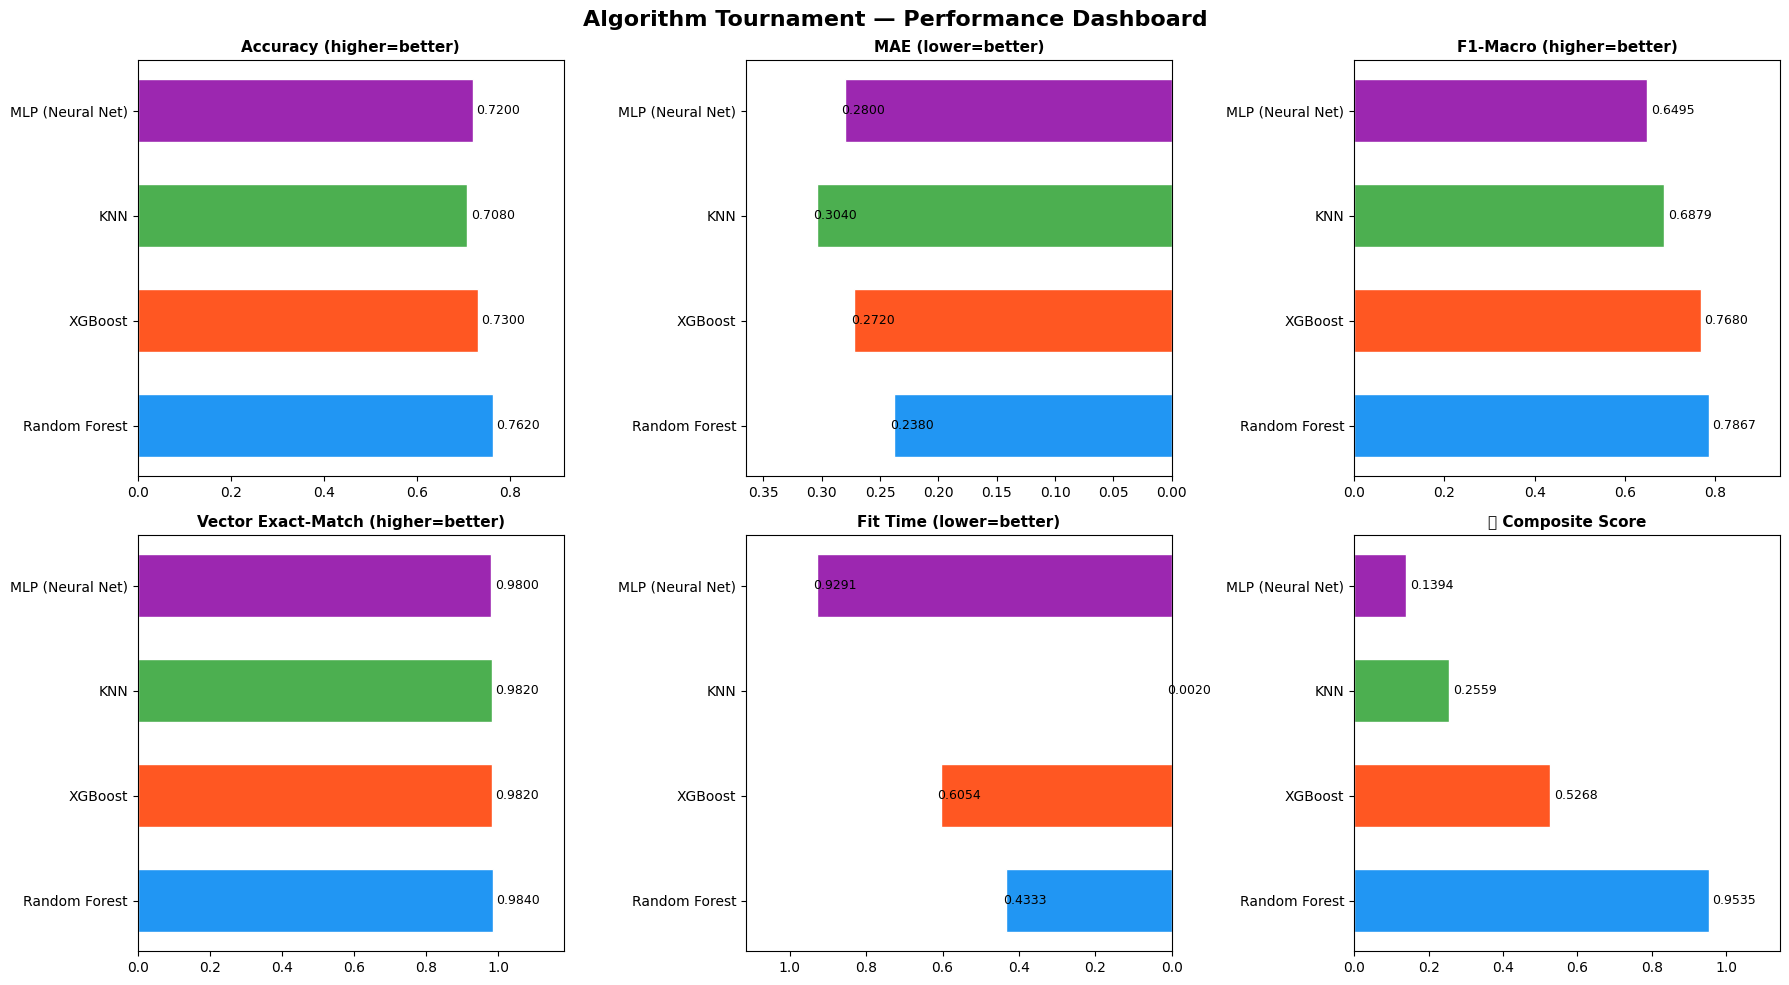

Chart saved → tournament_results.png


In [17]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Algorithm Tournament — Performance Dashboard', fontsize=16, fontweight='bold')
palette = ['#2196F3','#FF5722','#4CAF50','#9C27B0','#FF9800']
alg_names = df_res['Algorithm'].tolist()

metrics = [
    ('Accuracy',           'Accuracy (higher=better)',      True),
    ('MAE',                'MAE (lower=better)',            False),
    ('F1-Macro',           'F1-Macro (higher=better)',      True),
    ('Vector Exact-Match', 'Vector Exact-Match (higher=better)', True),
    ('Fit Time (s)',       'Fit Time (lower=better)',       False),
    ('Composite Score',    '⭐ Composite Score',             True),
]

for ax, (metric, label, higher_better) in zip(axes.flat, metrics):
    vals = df_res.set_index('Algorithm')[metric].reindex(alg_names)
    colors = [palette[i] for i in range(len(alg_names))]
    bars = ax.barh(alg_names, vals, color=colors, edgecolor='white', height=0.6)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlim(0, vals.max() * 1.2)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_width() + vals.max()*0.01, bar.get_y()+bar.get_height()/2,
                f'{v:.4f}', va='center', fontsize=9)
    if not higher_better:
        ax.invert_xaxis()

plt.tight_layout()
plt.savefig('tournament_results.png', dpi=130, bbox_inches='tight')
plt.show()
print('Chart saved → tournament_results.png')

## 9 · Winner — Confusion Matrix & Classification Report

In [18]:
winner_name = df_res.iloc[0]['Algorithm']
winner_res   = next(r for r in results if r['Algorithm'] == winner_name)
ys_pred_w    = winner_res['_ys_pred']

print(f'🥇 Winner: {winner_name}\n')
print('=== Classification Report (Score) ===')
print(classification_report(ys_te, ys_pred_w, zero_division=0))

# Confusion matrix
classes = sorted(df['user_score'].unique())
cm = confusion_matrix(ys_te, ys_pred_w, labels=classes)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=ax,
            linewidths=0.5, linecolor='#e0e0e0')
ax.set_title(f'{winner_name} — Confusion Matrix (user_score)', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved → confusion_matrix.png')

KeyError: '_ys_pred'

## 10 · Feature Importance (tree-based models)

KeyError: '_score_pipe'

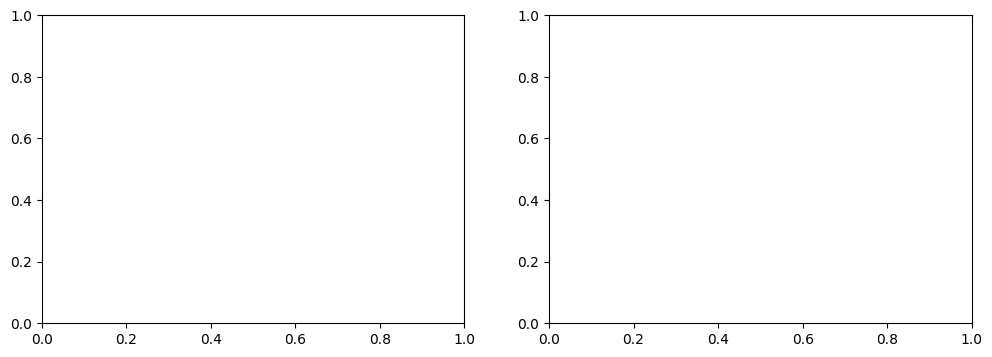

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
tree_names = ['Random Forest', 'XGBoost']

for ax, tname in zip(axes, tree_names):
    res = next((r for r in results if r['Algorithm'] == tname), None)
    if res is None:
        ax.set_visible(False); continue
    pipe = res['_score_pipe']
    clf_inner = pipe.named_steps['clf'] if hasattr(pipe, 'named_steps') else pipe
    importances = clf_inner.feature_importances_
    ax.barh(FEATURES, importances, color=['#FF5722','#2196F3','#4CAF50','#9C27B0'])
    ax.set_title(f'{tname} — Feature Importance', fontweight='bold')
    ax.set_xlabel('Importance')
    for i, v in enumerate(importances):
        ax.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved → feature_importance.png')

## 11 · Vector Accuracy — Per Dimension Breakdown

In [20]:
print('Per-dimension vector accuracy for each algorithm:\n')
vec_rows = []
for r in results:
    row = {'Algorithm': r['Algorithm']}
    for vi, vname in enumerate(VEC_TARGETS):
        col_acc = accuracy_score(yv_te[:, vi], r['_yv_pred'][:, vi])
        row[vname] = round(col_acc, 4)
    row['Exact Match'] = r['Vector Exact-Match']
    vec_rows.append(row)

df_vec = pd.DataFrame(vec_rows).sort_values('Exact Match', ascending=False)
print(df_vec.to_string(index=False))

# Heatmap
fig, ax = plt.subplots(figsize=(9, 4))
heat_data = df_vec.set_index('Algorithm')[VEC_TARGETS + ['Exact Match']]
sns.heatmap(heat_data, annot=True, fmt='.4f', cmap='YlGn', ax=ax,
            linewidths=0.5, vmin=0.7, vmax=1.0)
ax.set_title('Vector Accuracy per Dimension', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('vector_accuracy.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved → vector_accuracy.png')

Per-dimension vector accuracy for each algorithm:



KeyError: '_yv_pred'

## 12 · Tier-Level Accuracy (Optimal / Slight / Big Change)

In [ ]:
def tier(s):
    if s >= 8: return 'Optimal (>=8)'
    elif s >= 6: return 'Slight (6-7)'
    else: return 'Big Change (<6)'

tier_results = []
for r in results:
    row = {'Algorithm': r['Algorithm']}
    for t in ['Optimal (>=8)', 'Slight (6-7)', 'Big Change (<6)']:
        mask = np.array([tier(s) == t for s in ys_te])
        if mask.sum() > 0:
            row[t] = round(accuracy_score(ys_te[mask], r['_ys_pred'][mask]), 4)
        else:
            row[t] = None
    tier_results.append(row)

df_tier = pd.DataFrame(tier_results)
print(df_tier.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
df_plot = df_tier.set_index('Algorithm')[['Big Change (<6)','Slight (6-7)','Optimal (>=8)']]
sns.heatmap(df_plot, annot=True, fmt='.4f', cmap='RdYlGn', ax=ax,
            linewidths=0.5, vmin=0.5, vmax=1.0)
ax.set_title('Accuracy per Productivity Tier', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('tier_accuracy.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved → tier_accuracy.png')

## 13 · 🏆 Final Verdict

In [ ]:
print('=' * 60)
print('           ALGORITHM TOURNAMENT — FINAL VERDICT')
print('=' * 60)

for rank, row in df_res[display_cols].iterrows():
    medal = {1:'🥇', 2:'🥈', 3:'🥉'}.get(rank, f'  #{rank}')
    print(f'{medal}  {row["Algorithm"]:<22}  '
          f'Acc={row["Accuracy"]:.4f}  '
          f'MAE={row["MAE"]:.4f}  '
          f'F1={row["F1-Macro"]:.4f}  '
          f'Vec={row["Vector Exact-Match"]:.4f}  '
          f'Composite={row["Composite Score"]:.4f}')

winner_name = df_res.iloc[0]['Algorithm']
print(f'\n→ RECOMMENDED ALGORITHM: {winner_name}')
print(f'  Use this model in your production Python script.')
print('=' * 60)
print('\nShare the leaderboard table above when requesting the production script.')